C:\Users\301-23\AppData\Local\Temp\ipykernel_1836\2491641903.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cancer, x='target', palette='Set2')


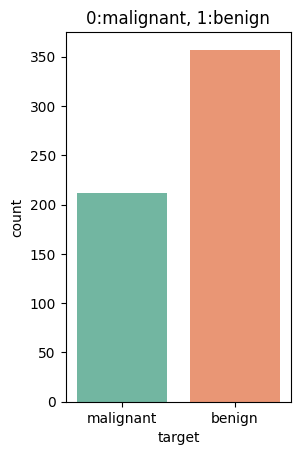

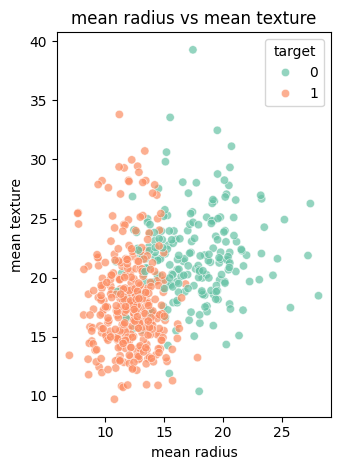

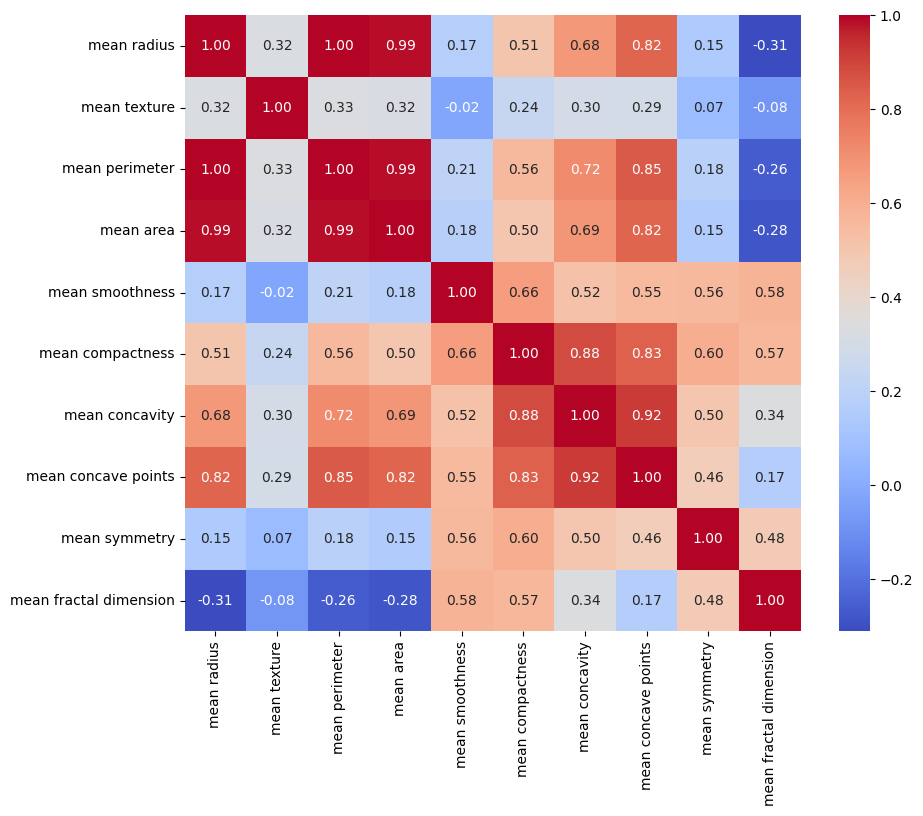

In [15]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
import seaborn as sns  #통계 시각화
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_cancer['target'] = cancer.target
#타겟 분포
plt.subplot(1,2,1)  #1행 2열 왼1쪽부터
sns.countplot(data=df_cancer, x='target', palette='Set2')
plt.title('0:malignant, 1:benign')
plt.xticks(ticks=[0,1], labels=cancer.target_names)
plt.show()

#주요변수
plt.subplot(1,2,2)
sns.scatterplot(data=df_cancer, x='mean radius', y='mean texture', hue='target',palette='Set2', alpha=0.7)
plt.title('mean radius vs mean texture')
plt.tight_layout()

plt.show()


#상관관계 히트맵(상위 10개 확장)
plt.figure(figsize = (10,8))
corr = df_cancer.iloc[:, :10].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.show()



base정확도 : 0.8860
              precision    recall  f1-score   support

   malignant       0.93      0.72      0.81        39
      benign       0.87      0.97      0.92        75

    accuracy                           0.89       114
   macro avg       0.90      0.85      0.86       114
weighted avg       0.89      0.89      0.88       114



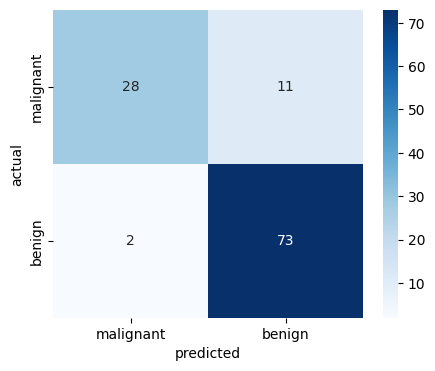

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

x_train, x_test, y_train, y_test = train_test_split(cancer.data,cancer.target,test_size=0.2,random_state=21)
svm_base_model = SVC(kernel='rbf', random_state=1)
svm_base_model.fit(x_train, y_train)
y_pred = svm_base_model.predict(x_test)
print(f'base정확도 : {accuracy_score(y_test,y_pred):.4f}')
print(classification_report(y_test,y_pred, target_names=cancer.target_names))
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize = (5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.ylabel('actual')
plt.xlabel('predicted')
plt.show()

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
param_grid = {'C':[0.1,1,10,100] # c값이 작을경우 소프트 마진, 클수록 하드마진 0.001 - 1000
    ,'gamma':[1,0.1,0.01,0.001] #결정 경계의 굴곡 조절클수록 복잡해짐
    ,'kernel':['rbf']
              }
grid = GridSearchCV(SVC(random_state=42), param_grid, refit=True, cv=5)
# grid.fit(x_train, y_train)
grid.fit(x_train_scaled, y_train)
print(f'최적의 하이파라미터:{grid.best_params_}')
print(f'최고 정확도 :{grid.best_score_:.4f}')
print("============")
# best_pred = grid.predict(x_test)
best_pred = grid.predict(x_test_scaled)
print(f'튜닝 후 test 정확도:{accuracy_score(y_test,best_pred):.4f}')
tune_cm = confusion_matrix(y_test,best_pred)
print(tune_cm)

최적의 하이파라미터:{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
최고 정확도 :0.9670
튜닝 후 test 정확도:0.9825
[[38  1]
 [ 1 74]]
